# Weather- and Lighting-Robust Traffic Sign Classification — Demo

This demo runs the trained **multi-task ResNet-18** on real-world adverse-condition images
and shows two predictions per image:

1. **Traffic sign class** (43-way GTSRB classification) — primary task
2. **Adverse condition type** (8-way: clean / low_brightness / overexposure / shadow / fog / rain / motion_blur / low_contrast) — auxiliary task

The auxiliary head was trained jointly to force the backbone to encode degradation features
explicitly, which improves generalization to corrupted inputs.

**No training is performed in this notebook** — it only loads a pretrained model and runs
inference on sample images.

---
### How to run
1. Open in Google Colab.
2. Run cells top to bottom.
3. When prompted, upload `multitask_resnet18.pth`.
4. When prompted, upload `real_adverse_converted.zip` (uncropped scenes).
5. When prompted, upload `real_cropped.zip` (cropped + labeled signs) to also see real-world accuracy.

## 1. Setup

In [1]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile, shutil, json, os, math
from collections import defaultdict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. Class and condition labels

In [2]:
class_names = {
     0: "Speed limit (20km/h)",      1: "Speed limit (30km/h)",
     2: "Speed limit (50km/h)",      3: "Speed limit (60km/h)",
     4: "Speed limit (70km/h)",      5: "Speed limit (80km/h)",
     6: "End of speed limit (80km/h)", 7: "Speed limit (100km/h)",
     8: "Speed limit (120km/h)",     9: "No passing",
    10: "No passing for vehicles over 3.5 metric tons",
    11: "Right-of-way at the next intersection", 12: "Priority road",
    13: "Yield", 14: "Stop", 15: "No vehicles",
    16: "Vehicles over 3.5 metric tons prohibited", 17: "No entry",
    18: "General caution",          19: "Dangerous curve to the left",
    20: "Dangerous curve to the right", 21: "Double curve",
    22: "Bumpy road",               23: "Slippery road",
    24: "Road narrows on the right", 25: "Road work",
    26: "Traffic signals",          27: "Pedestrians",
    28: "Children crossing",        29: "Bicycles crossing",
    30: "Beware of ice/snow",       31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",         34: "Turn left ahead",
    35: "Ahead only",               36: "Go straight or right",
    37: "Go straight or left",      38: "Keep right",
    39: "Keep left",                40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 metric tons",
}

condition_names = {
    0: "clean",          1: "low_brightness", 2: "overexposure", 3: "shadow",
    4: "fog",            5: "rain",           6: "motion_blur",  7: "low_contrast",
}

NUM_CLASSES = 43
NUM_CONDITIONS = 8


## 3. Multi-task ResNet-18 architecture

ResNet-18 backbone with two parallel output heads — sign (43 classes) and condition (8 classes).

In [3]:
class MultiTaskResNet18(nn.Module):
    """Shared ResNet-18 backbone with two output heads."""
    def __init__(self, num_classes=43, num_conditions=8):
        super().__init__()
        backbone = models.resnet18(weights=None)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.sign_head      = nn.Linear(feat_dim, num_classes)
        self.condition_head = nn.Linear(feat_dim, num_conditions)

    def forward(self, x):
        feats = self.backbone(x)
        return self.sign_head(feats), self.condition_head(feats)


## 4. Upload pretrained multi-task model

In [4]:
from google.colab import files

print("Please upload the pretrained model file: multitask_resnet18.pth")
uploaded_model = files.upload()

Path("models").mkdir(exist_ok=True)
model_found = False
for fn in uploaded_model:
    if fn.endswith(".pth"):
        shutil.move(fn, "models/multitask_resnet18.pth")
        model_found = True
        print(f"Saved as: models/multitask_resnet18.pth")

if not model_found:
    print("ERROR: No .pth file uploaded.")


Please upload the pretrained model file: multitask_resnet18.pth


Saving multitask_resnet18.pth to multitask_resnet18.pth
Saved as: models/multitask_resnet18.pth


## 5. Load model

In [5]:
MODEL_PATH = "models/multitask_resnet18.pth"

model = MultiTaskResNet18(NUM_CLASSES, NUM_CONDITIONS)
state = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state)
model = model.to(device).eval()
print("Multi-task ResNet-18 loaded.")
print(f"  Sign head:      {NUM_CLASSES} classes")
print(f"  Condition head: {NUM_CONDITIONS} classes")


Multi-task ResNet-18 loaded.
  Sign head:      43 classes
  Condition head: 8 classes


## 6. Image preprocessing pipeline

In [6]:
# Match the exact preprocessing used during training (64x64 + ImageNet normalization)
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])
print("Preprocessing pipeline ready.")


Preprocessing pipeline ready.


## 7. Upload sample images

In [7]:
print("Please upload the sample image zip: real_adverse_converted.zip (uncropped scenes)")
uploaded_data = files.upload()

for fn in uploaded_data:
    if fn.endswith(".zip"):
        with zipfile.ZipFile(fn, "r") as z:
            z.extractall("/content")
        print(f"Extracted: {fn}")

DATA_DIR = Path("/content/real_adverse_converted")
print("Data folder exists:", DATA_DIR.exists())
if DATA_DIR.exists():
    for d in sorted(DATA_DIR.iterdir()):
        if d.is_dir() and not d.name.startswith("."):
            n = len([f for f in d.glob("*.jpg") if not f.name.startswith(".")])
            print(f"  {d.name}/  ({n} images)")


Please upload the sample image zip: real_adverse_converted.zip (uncropped scenes)


Saving real_adverse_converted.zip to real_adverse_converted.zip
Extracted: real_adverse_converted.zip
Data folder exists: True
  fog/  (6 images)
  glare/  (6 images)
  night/  (6 images)
  rain/  (6 images)


## 8. Multi-task prediction function

In [8]:
def predict_multi(model, img_path, transform):
    """Run multi-task inference on a single image. Returns sign + condition predictions."""
    img = Image.open(img_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        sign_logits, cond_logits = model(x)
        sign_probs = torch.softmax(sign_logits, dim=1)
        cond_probs = torch.softmax(cond_logits, dim=1)
        s_conf, s_pred = torch.max(sign_probs, dim=1)
        c_conf, c_pred = torch.max(cond_probs, dim=1)
    return {
        "image":     img,
        "pred_sign": int(s_pred.cpu()),
        "sign_conf": float(s_conf.cpu()),
        "pred_cond": int(c_pred.cpu()),
        "cond_conf": float(c_conf.cpu()),
    }

print("Prediction function ready.")


Prediction function ready.


## 9. Inference on uncropped real-world scenes (qualitative)

These wide-scene images are out-of-distribution — the model was trained on cropped 64×64
sign images. We test it here to see how the **condition prediction** behaves on real
adverse imagery, and to demonstrate prediction stability under domain shift.

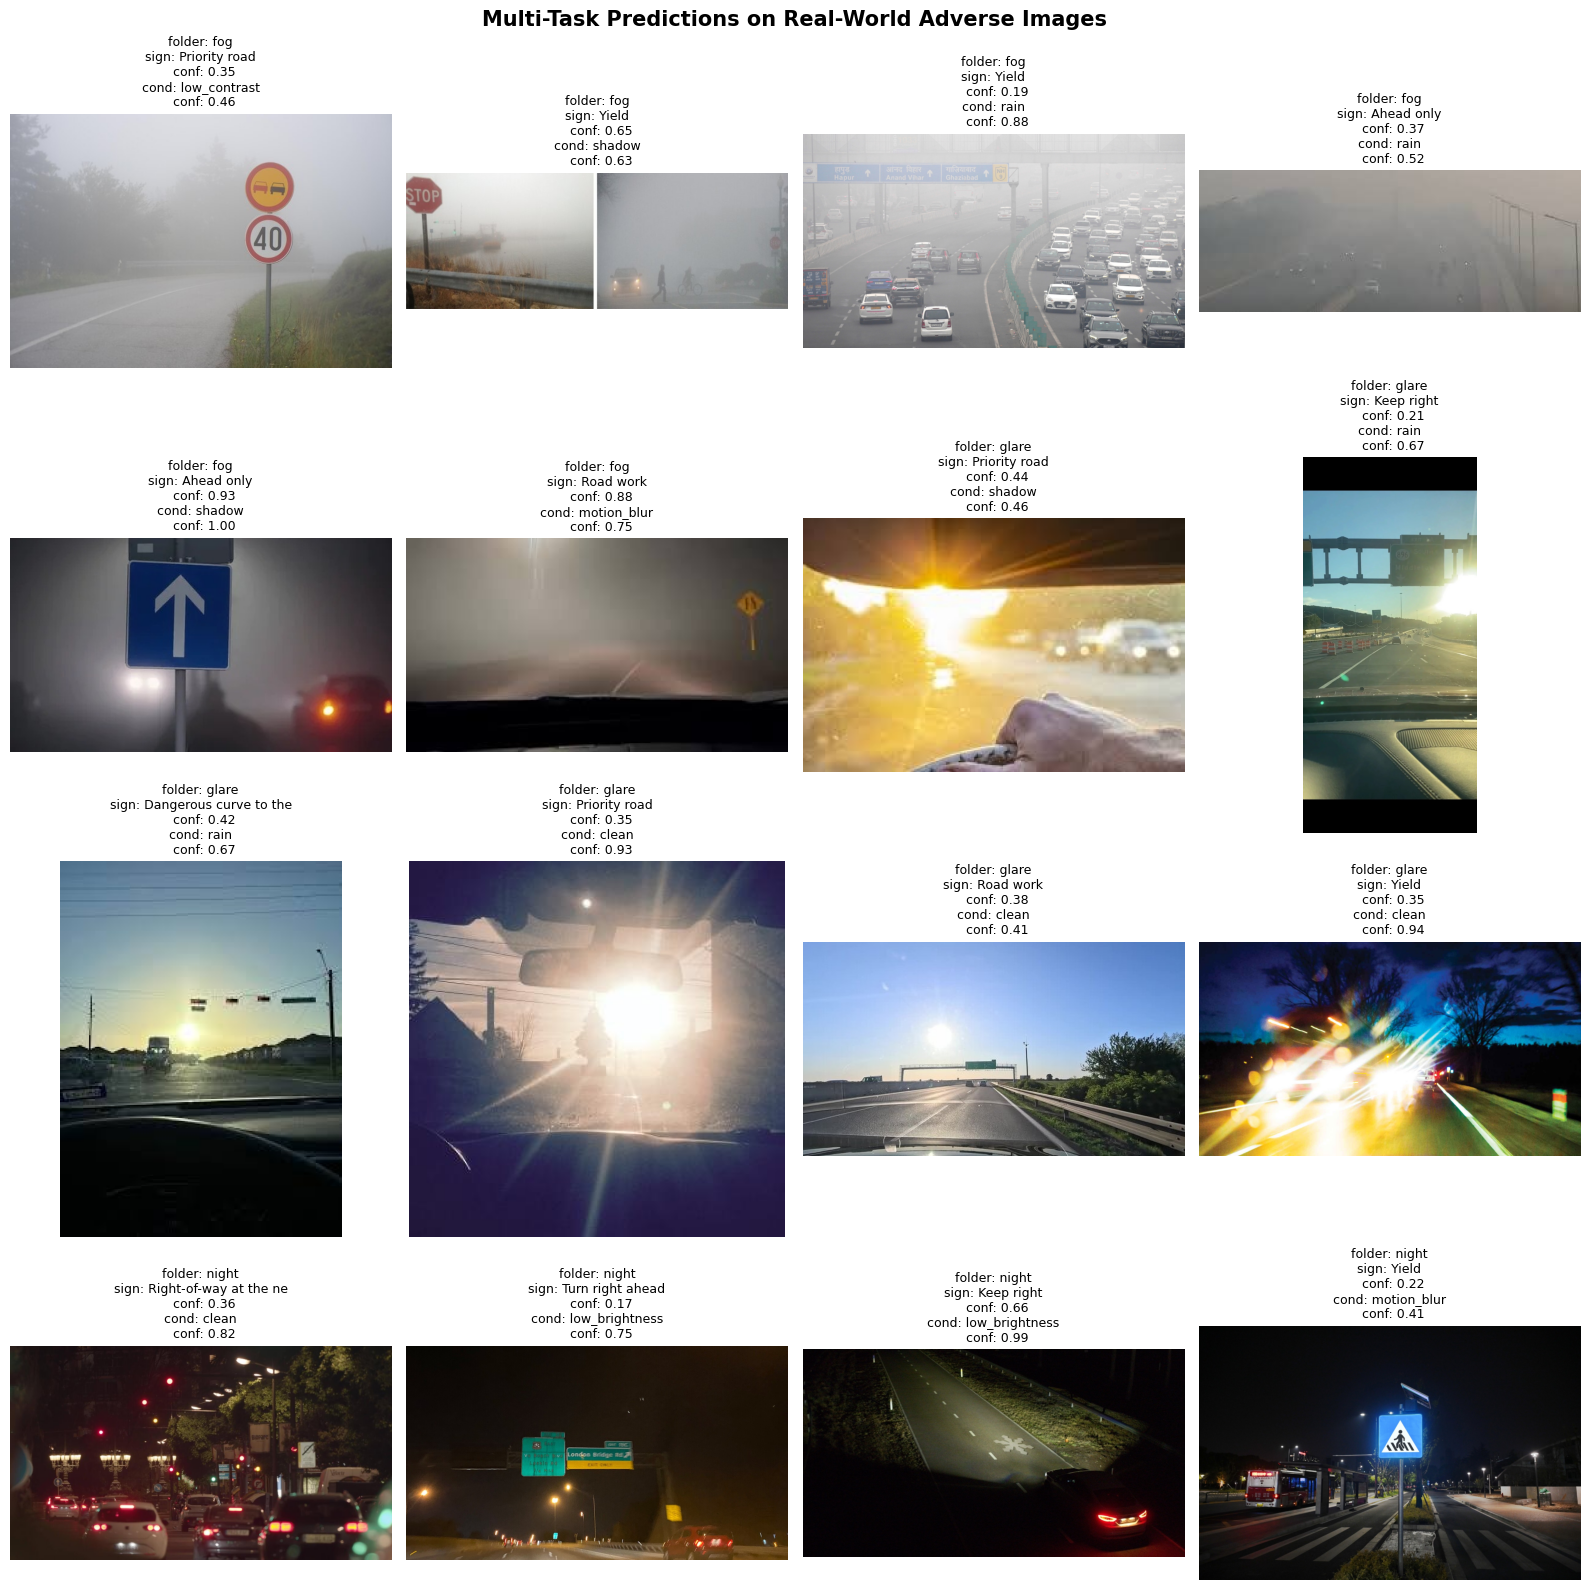

In [9]:
def visualize_predictions(model, data_dir, max_images=16):
    images_data = []
    for cond_folder in sorted(data_dir.iterdir()):
        if cond_folder.is_dir() and not cond_folder.name.startswith("."):
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:
                for img_path in sorted(cond_folder.glob(ext)):
                    if img_path.name.startswith("."):
                        continue
                    r = predict_multi(model, img_path, transform)
                    r["folder"] = cond_folder.name
                    r["filename"] = img_path.name
                    images_data.append(r)

    if not images_data:
        print("No images found.")
        return

    images_data = images_data[:max_images]
    cols = 4
    rows = math.ceil(len(images_data) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4.2 * rows))
    axes = axes.flatten() if rows * cols > 1 else [axes]

    for i, d in enumerate(images_data):
        axes[i].imshow(d["image"])
        axes[i].axis("off")
        sign_str = class_names[d["pred_sign"]][:22]
        cond_str = condition_names[d["pred_cond"]]
        axes[i].set_title(
            f"folder: {d['folder']}\n"
            f"sign: {sign_str}\n  conf: {d['sign_conf']:.2f}\n"
            f"cond: {cond_str}\n  conf: {d['cond_conf']:.2f}",
            fontsize=9
        )
    for j in range(len(images_data), len(axes)):
        axes[j].axis("off")

    fig.suptitle("Multi-Task Predictions on Real-World Adverse Images",
                 fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

visualize_predictions(model, DATA_DIR)


## 10. Per-folder confidence and condition-prediction summary

In [10]:
def summarize(model, data_dir):
    summary = defaultdict(lambda: {"sign_confs": [], "cond_confs": [], "cond_preds": []})
    for cond_folder in sorted(data_dir.iterdir()):
        if cond_folder.is_dir() and not cond_folder.name.startswith("."):
            for ext in ["*.jpg", "*.jpeg", "*.png", "*.webp"]:
                for img_path in sorted(cond_folder.glob(ext)):
                    if img_path.name.startswith("."):
                        continue
                    r = predict_multi(model, img_path, transform)
                    summary[cond_folder.name]["sign_confs"].append(r["sign_conf"])
                    summary[cond_folder.name]["cond_confs"].append(r["cond_conf"])
                    summary[cond_folder.name]["cond_preds"].append(condition_names[r["pred_cond"]])

    print("Real-world (uncropped) folder summary:")
    print("-" * 70)
    for cond, vals in summary.items():
        n = len(vals["sign_confs"])
        avg_s = sum(vals["sign_confs"]) / n if n else 0
        avg_c = sum(vals["cond_confs"]) / n if n else 0
        # Most-frequent predicted condition
        from collections import Counter
        top_cond = Counter(vals["cond_preds"]).most_common(1)[0] if n else ("?", 0)
        print(f"  {cond:8s}  N={n:2d}  "
              f"avg sign_conf={avg_s:.3f}  "
              f"avg cond_conf={avg_c:.3f}  "
              f"top cond_pred={top_cond[0]} ({top_cond[1]}/{n})")

summarize(model, DATA_DIR)


Real-world (uncropped) folder summary:
----------------------------------------------------------------------
  fog       N= 6  avg sign_conf=0.563  avg cond_conf=0.706  top cond_pred=shadow (2/6)
  glare     N= 6  avg sign_conf=0.360  avg cond_conf=0.681  top cond_pred=clean (3/6)
  night     N= 6  avg sign_conf=0.426  avg cond_conf=0.665  top cond_pred=low_brightness (2/6)
  rain      N= 6  avg sign_conf=0.424  avg cond_conf=0.923  top cond_pred=rain (3/6)


## 11. Cropped real-world accuracy



In [11]:
print("Optional: upload real_cropped.zip if you have it (skip if not).")
uploaded_cropped = files.upload()

for fn in uploaded_cropped:
    if fn.endswith(".zip"):
        with zipfile.ZipFile(fn, "r") as z:
            z.extractall("/content")
        print(f"Extracted: {fn}")

CROPPED_DIR = Path("/content/real_cropped")
print("Cropped folder exists:", CROPPED_DIR.exists())


Optional: upload real_cropped.zip if you have it (skip if not).


Saving real_cropped.zip to real_cropped.zip
Extracted: real_cropped.zip
Cropped folder exists: True



Real-world cropped accuracy: 0.7273  (correct: 8/11)

By condition folder:
        sum  count  mean
folder                  
fog       2      4   0.5
glare     1      2   0.5
night     2      2   1.0
rain      3      3   1.0


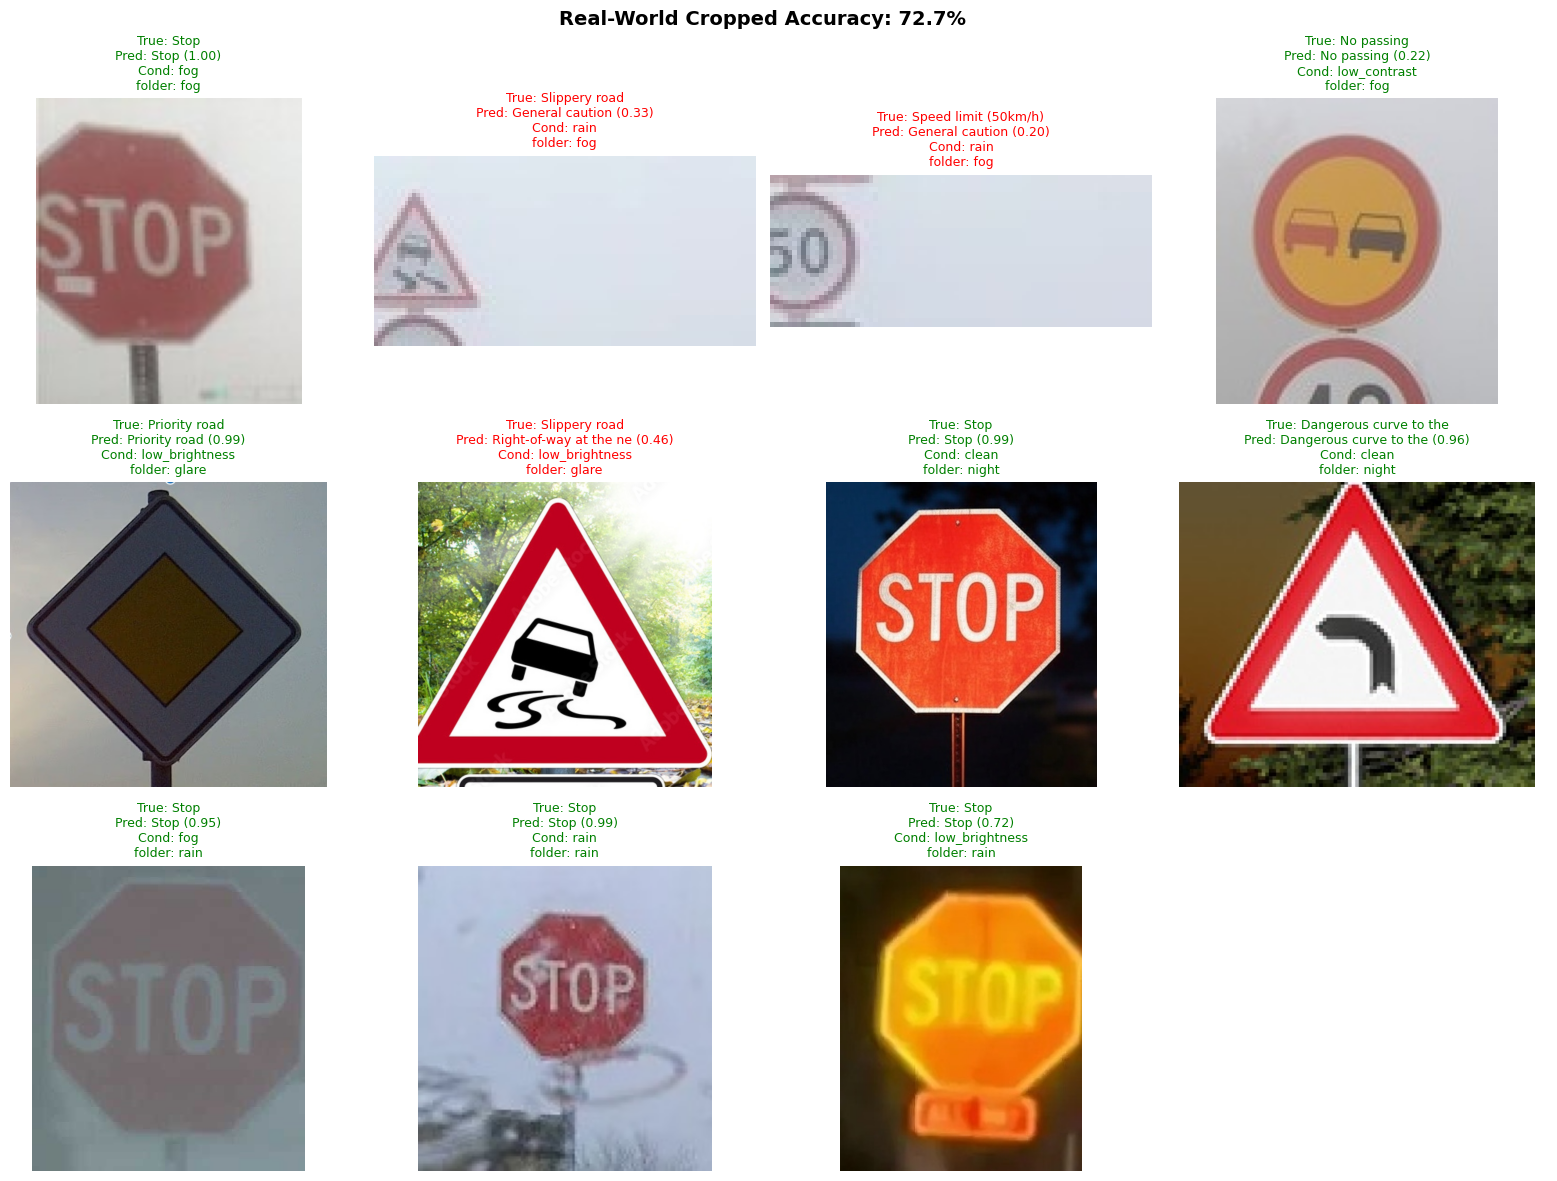

In [12]:
import pandas as pd

if CROPPED_DIR.exists():
    records = []
    for cond_folder in sorted(CROPPED_DIR.iterdir()):
        if cond_folder.is_dir() and not cond_folder.name.startswith("."):
            for img_path in sorted(cond_folder.glob("*.jpg")):
                if img_path.name.startswith("."):
                    continue
                # parse class id from filename prefix
                try:
                    cls_id = int(img_path.stem.split("_")[0])
                except Exception:
                    print(f"Skipping (can't parse class): {img_path.name}")
                    continue
                r = predict_multi(model, img_path, transform)
                r["true_class"] = cls_id
                r["correct"] = (r["pred_sign"] == cls_id)
                r["folder"] = cond_folder.name
                r["filename"] = img_path.name
                records.append(r)

    if records:
        df = pd.DataFrame([{k: v for k, v in r.items() if k != "image"} for r in records])
        overall = df["correct"].mean()
        print(f"\nReal-world cropped accuracy: {overall:.4f}  (correct: {df['correct'].sum()}/{len(df)})")
        print("\nBy condition folder:")
        print(df.groupby("folder")["correct"].agg(["sum", "count", "mean"]).round(3))

        # Visualize predictions
        n = len(records)
        cols = 4
        rows = math.ceil(n / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
        axes = axes.flatten() if n > 1 else [axes]
        for i, r in enumerate(records):
            axes[i].imshow(r["image"])
            axes[i].axis("off")
            true_name = class_names[r["true_class"]][:22]
            pred_name = class_names[r["pred_sign"]][:22]
            cond_name = condition_names[r["pred_cond"]]
            color = "green" if r["correct"] else "red"
            axes[i].set_title(
                f"True: {true_name}\n"
                f"Pred: {pred_name} ({r['sign_conf']:.2f})\n"
                f"Cond: {cond_name}\nfolder: {r['folder']}",
                fontsize=9, color=color
            )
        for j in range(n, len(axes)):
            axes[j].axis("off")
        fig.suptitle(f"Real-World Cropped Accuracy: {overall:.1%}",
                     fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()
    else:
        print("No cropped images found.")
else:
    print("(Skipped) no real_cropped.zip uploaded.")


---
## Demo Summary

The multi-task ResNet-18 produces **two predictions per image**:
- The traffic sign class (1-of-43, GTSRB taxonomy)
- The adverse condition type (1-of-8, our synthetic-corruption taxonomy)

The condition head is the auxiliary task: by training the backbone to predict *what kind*
of adverse condition is present, we encourage features that are stable across degradation
types, which directly improves robustness on the primary sign-classification task.

**Quantitative evaluation** lives in the training notebook (`metrics.csv`) — per-condition
accuracy across all 8 conditions for Baseline, Augmented, and Multi-Task models, plus the
corruption-probability ablation.